In [3]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error
)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [5]:
# =========================================================
# LOAD OPTIMIZED SHEET
# =========================================================

file_path = "Data_file.xlsx"

optimized_df = pd.read_excel(
    file_path,
    sheet_name='Optimized'
)

print("Optimized Sheet Loaded Successfully!")
print()

print("Dataset Shape:")
print(optimized_df.shape)

print()
print("="*60)
print("FIRST 5 ROWS")
print("="*60)

display(optimized_df.head())

Optimized Sheet Loaded Successfully!

Dataset Shape:
(61, 21)

FIRST 5 ROWS


,Jsc,v(V),jtot(mA/cm2),Unnamed: 3,Q.E.(%),lambda(nm),QE(%),Unnamed: 7,R(A/W),lambda(nm).1,...,Unnamed: 11,Unnamed: 12,Unnamed: 13,Detectivity (J),V(V),Jsc for (Id),D*,Unnamed: 18,Unnamed: 19,Dark current at 0.1 V
0,NaN,0.00,24.680453,NaN,NaN,300,84.57874,NaN,NaN,300,...,NaN,NaN,NaN,NaN,1.20,48572.84940,5.065000e+15,NaN,(2*Id*e)^0.5,4.035839e-14
1,NaN,0.05,24.680182,NaN,NaN,310,85.55837,NaN,NaN,310,...,NaN,NaN,NaN,NaN,1.15,24802.79350,5.294454e+15,NaN,NaN,NaN
2,NaN,0.10,24.679882,NaN,NaN,320,86.56992,NaN,NaN,320,...,NaN,NaN,NaN,NaN,1.10,11929.53900,5.529858e+15,NaN,NaN,NaN
3,NaN,0.15,24.679546,NaN,NaN,330,87.62653,NaN,NaN,330,...,NaN,NaN,NaN,NaN,1.05,5290.85414,5.772268e+15,NaN,NaN,NaN
4,NaN,0.20,24.679165,NaN,NaN,340,88.74698,NaN,NaN,340,...,NaN,NaN,NaN,NaN,1.00,1955.99145,6.023230e+15,NaN,NaN,NaN


In [6]:
# =========================================================
# J-V DATA PREPROCESSING
# =========================================================

jv_df = optimized_df[[' v(V)', 'jtot(mA/cm2)']].copy()

# Rename columns
jv_df.rename(
    columns={
        ' v(V)': 'Voltage',
        'jtot(mA/cm2)': 'Current'
    },
    inplace=True
)

# Remove NaN values
jv_df.dropna(inplace=True)

# Convert to numeric
jv_df['Voltage'] = pd.to_numeric(jv_df['Voltage'])
jv_df['Current'] = pd.to_numeric(jv_df['Current'])

# Reset index
jv_df.reset_index(drop=True, inplace=True)

print("J-V Data Ready!")
print()

print("Shape:")
print(jv_df.shape)

print()
print(jv_df.head())

J-V Data Ready!

Shape:
(18, 2)

   Voltage    Current
0     0.00  24.680453
1     0.05  24.680182
2     0.10  24.679882
3     0.15  24.679546
4     0.20  24.679165


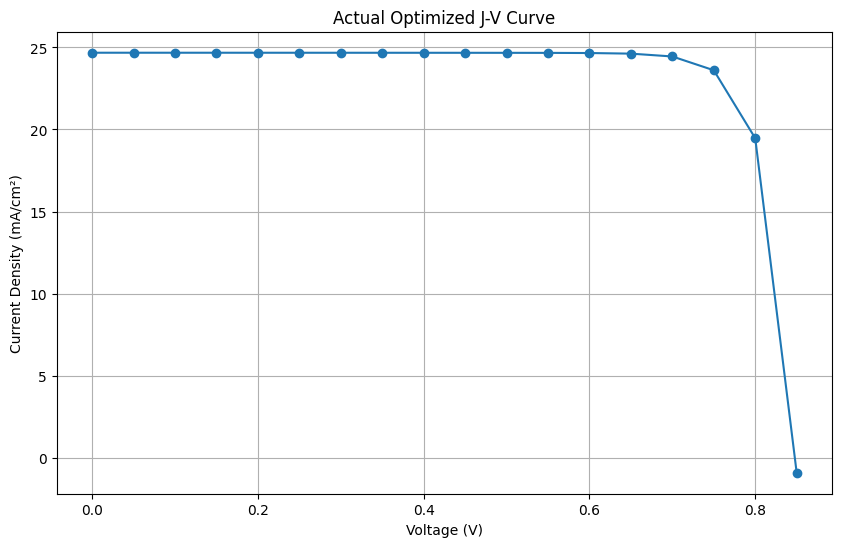

In [7]:
# =========================================================
# PLOT ACTUAL J-V CURVE
# =========================================================

plt.figure(figsize=(10,6))

plt.plot(
    jv_df['Voltage'],
    jv_df['Current'],
    marker='o'
)

plt.title("Actual Optimized J-V Curve")

plt.xlabel("Voltage (V)")
plt.ylabel("Current Density (mA/cm²)")

plt.grid(True)

plt.show()

In [8]:
# =========================================================
# J-V MACHINE LEARNING MODEL
# =========================================================

# Features and target
X_jv = jv_df[['Voltage']]
y_jv = jv_df['Current']

# Train-test split
X_train_jv, X_test_jv, y_train_jv, y_test_jv = train_test_split(
    X_jv,
    y_jv,
    test_size=0.2,
    random_state=42
)

# Model
jv_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train model
jv_model.fit(X_train_jv, y_train_jv)

# Predictions
y_pred_jv = jv_model.predict(X_test_jv)

print("J-V Model Trained Successfully!")

J-V Model Trained Successfully!


J-V MODEL PERFORMANCE
R² Score: 0.8559042726958324
MAE: 0.0005043356249521125


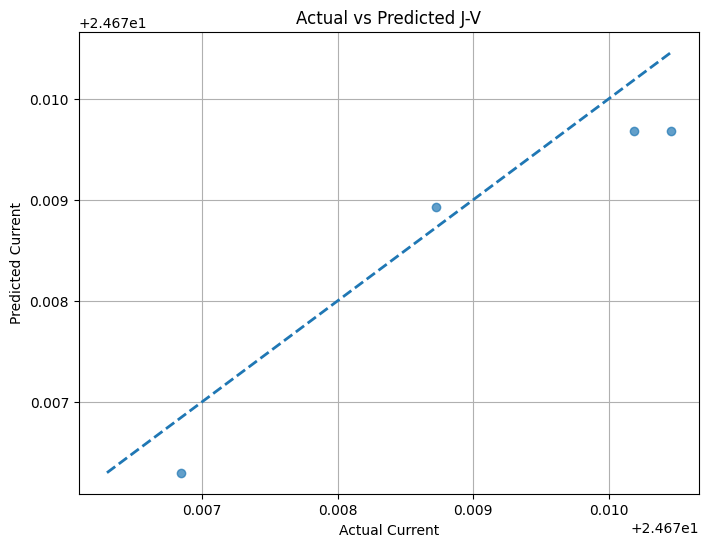

In [9]:
# =========================================================
# J-V MODEL VALIDATION
# =========================================================

# Performance Metrics
r2 = r2_score(y_test_jv, y_pred_jv)
mae = mean_absolute_error(y_test_jv, y_pred_jv)

print("J-V MODEL PERFORMANCE")
print("="*40)

print("R² Score:", r2)
print("MAE:", mae)

# =========================================================
# ACTUAL vs PREDICTED SCATTER PLOT
# =========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test_jv,
    y_pred_jv,
    alpha=0.7
)

# Ideal line
min_val = min(y_test_jv.min(), y_pred_jv.min())
max_val = max(y_test_jv.max(), y_pred_jv.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    '--',
    linewidth=2
)

plt.xlabel("Actual Current")
plt.ylabel("Predicted Current")

plt.title("Actual vs Predicted J-V")

plt.grid(True)

plt.show()

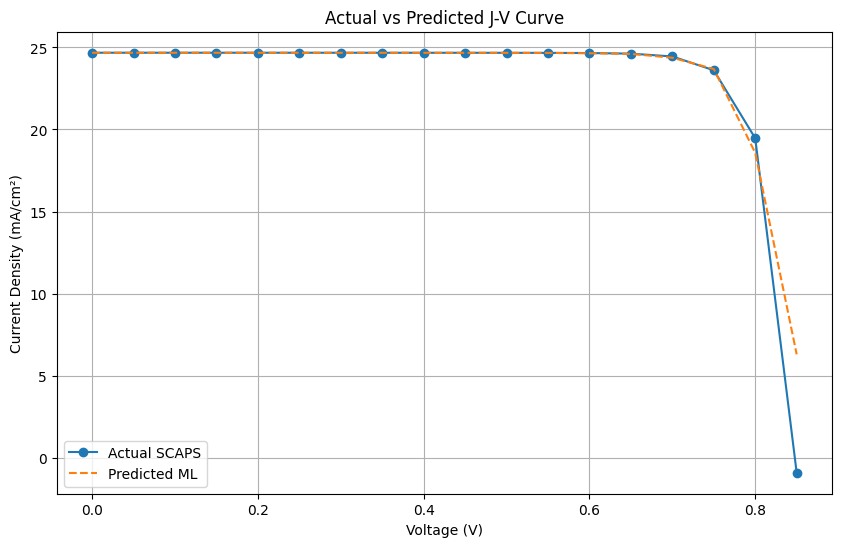

In [10]:
# =========================================================
# ACTUAL vs PREDICTED J-V CURVE
# =========================================================

# Predict full curve
full_pred_jv = jv_model.predict(X_jv)

# Plot
plt.figure(figsize=(10,6))

# Actual curve
plt.plot(
    jv_df['Voltage'],
    jv_df['Current'],
    marker='o',
    label='Actual SCAPS'
)

# Predicted curve
plt.plot(
    jv_df['Voltage'],
    full_pred_jv,
    '--',
    label='Predicted ML'
)

plt.title("Actual vs Predicted J-V Curve")

plt.xlabel("Voltage (V)")
plt.ylabel("Current Density (mA/cm²)")

plt.legend()
plt.grid(True)

plt.show()

In [11]:
# =========================================================
# J-V PREDICTION FUNCTION
# =========================================================

def predict_current(voltage):

    prediction = jv_model.predict([[voltage]])[0]

    print(f"Predicted Current Density at {voltage} V : {prediction}")

    return prediction

In [12]:
# =========================================================
# USER INPUT PREDICTION
# =========================================================

voltage = float(input("Enter Voltage (V): "))

predict_current(voltage)

Predicted Current Density at 4.0 V : 6.292587744110018


c:\Users\yashv\anaconda3\envs\py312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


np.float64(6.292587744110018)

In [13]:
# =========================================================
# FULL J-V CURVE PREDICTION FOR UNSEEN VOLTAGES
# =========================================================

def predict_jv_curve():

    voltage_range = np.linspace(
        jv_df['Voltage'].min(),
        jv_df['Voltage'].max(),
        300
    )

    predicted_current = jv_model.predict(
        voltage_range.reshape(-1,1)
    )

    plt.figure(figsize=(10,6))

    plt.plot(
        voltage_range,
        predicted_current
    )

    plt.title("Predicted J-V Curve")

    plt.xlabel("Voltage (V)")
    plt.ylabel("Predicted Current Density")

    plt.grid(True)

    plt.show()

c:\Users\yashv\anaconda3\envs\py312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


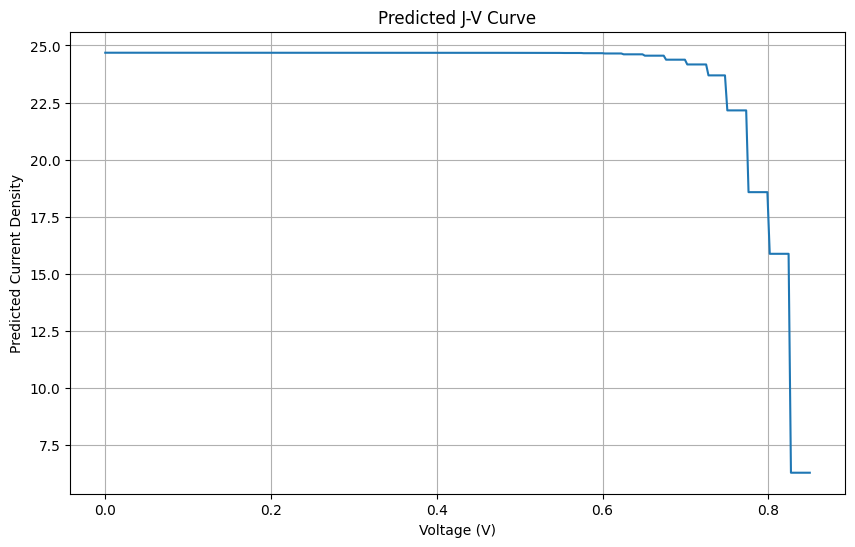

In [14]:
# =========================================================
# RUN FULL CURVE PREDICTION
# =========================================================

predict_jv_curve()

In [16]:
# =========================================================
# QE DATA PREPROCESSING
# =========================================================

qe_df = optimized_df[['lambda(nm)', '      QE(%)']].copy()

# Rename columns
qe_df.rename(
    columns={
        'lambda(nm)': 'Wavelength',
        '      QE(%)': 'QE'
    },
    inplace=True
)

# Remove NaN values
qe_df.dropna(inplace=True)

# Convert to numeric
qe_df['Wavelength'] = pd.to_numeric(qe_df['Wavelength'])
qe_df['QE'] = pd.to_numeric(qe_df['QE'])

# Reset index
qe_df.reset_index(drop=True, inplace=True)

print("QE Data Ready!")
print()

print("Shape:")
print(qe_df.shape)

print()
print(qe_df.head())

QE Data Ready!

Shape:
(61, 2)

   Wavelength        QE
0         300  84.57874
1         310  85.55837
2         320  86.56992
3         330  87.62653
4         340  88.74698


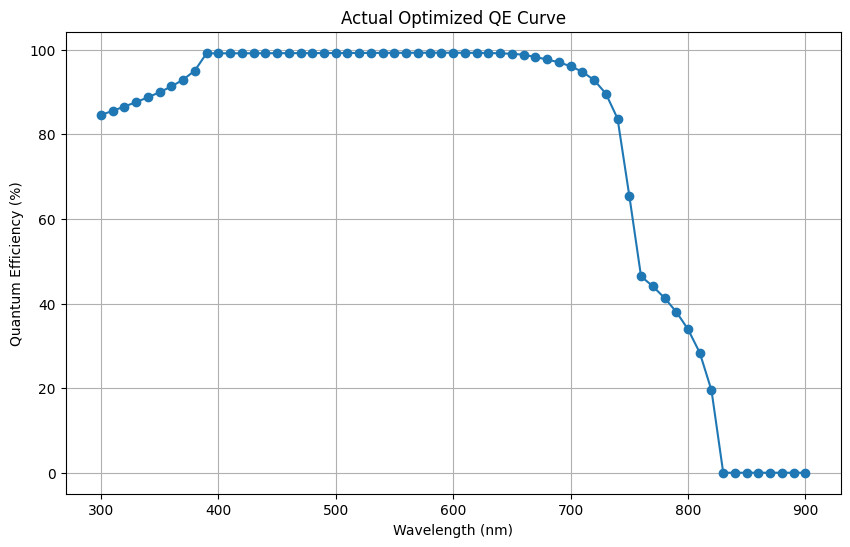

In [17]:
# =========================================================
# PLOT ACTUAL QE CURVE
# =========================================================

plt.figure(figsize=(10,6))

plt.plot(
    qe_df['Wavelength'],
    qe_df['QE'],
    marker='o'
)

plt.title("Actual Optimized QE Curve")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Quantum Efficiency (%)")

plt.grid(True)

plt.show()

In [18]:
# =========================================================
# QE MACHINE LEARNING MODEL
# =========================================================

# Features and target
X_qe = qe_df[['Wavelength']]
y_qe = qe_df['QE']

# Train-test split
X_train_qe, X_test_qe, y_train_qe, y_test_qe = train_test_split(
    X_qe,
    y_qe,
    test_size=0.2,
    random_state=42
)

# Model
qe_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train model
qe_model.fit(X_train_qe, y_train_qe)

# Predictions
y_pred_qe = qe_model.predict(X_test_qe)

print("QE Model Trained Successfully!")

QE Model Trained Successfully!


QE MODEL PERFORMANCE
R² Score: 0.9858794642447958
MAE: 1.4823678462651841


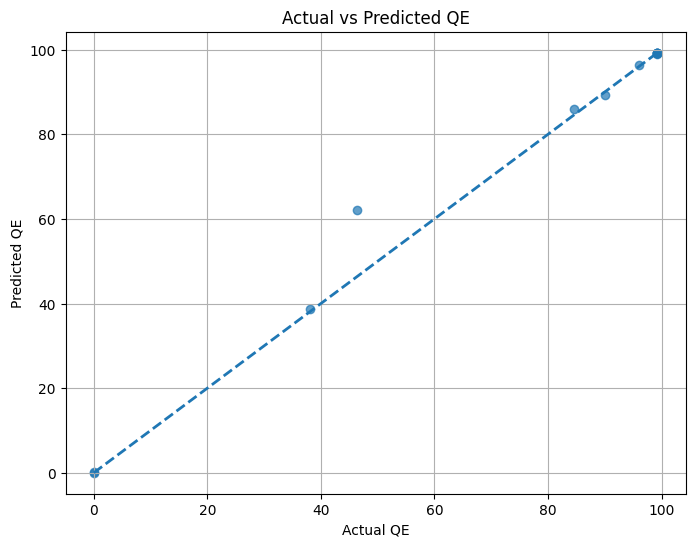

In [19]:
# =========================================================
# QE MODEL VALIDATION
# =========================================================

# Performance Metrics
r2 = r2_score(y_test_qe, y_pred_qe)
mae = mean_absolute_error(y_test_qe, y_pred_qe)

print("QE MODEL PERFORMANCE")
print("="*40)

print("R² Score:", r2)
print("MAE:", mae)

# =========================================================
# ACTUAL vs PREDICTED SCATTER PLOT
# =========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test_qe,
    y_pred_qe,
    alpha=0.7
)

# Ideal line
min_val = min(y_test_qe.min(), y_pred_qe.min())
max_val = max(y_test_qe.max(), y_pred_qe.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    '--',
    linewidth=2
)

plt.xlabel("Actual QE")
plt.ylabel("Predicted QE")

plt.title("Actual vs Predicted QE")

plt.grid(True)

plt.show()

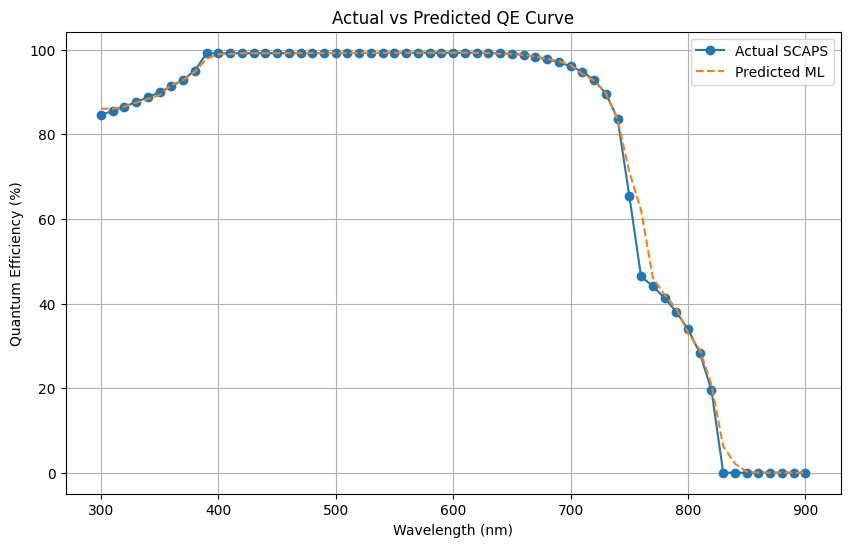

In [20]:
# =========================================================
# ACTUAL vs PREDICTED QE CURVE
# =========================================================

# Predict full curve
full_pred_qe = qe_model.predict(X_qe)

# Plot
plt.figure(figsize=(10,6))

# Actual curve
plt.plot(
    qe_df['Wavelength'],
    qe_df['QE'],
    marker='o',
    label='Actual SCAPS'
)

# Predicted curve
plt.plot(
    qe_df['Wavelength'],
    full_pred_qe,
    '--',
    label='Predicted ML'
)

plt.title("Actual vs Predicted QE Curve")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Quantum Efficiency (%)")

plt.legend()
plt.grid(True)

plt.show()

In [21]:
# =========================================================
# QE PREDICTION FUNCTION
# =========================================================

def predict_qe(wavelength):

    prediction = qe_model.predict([[wavelength]])[0]

    print(f"Predicted QE at {wavelength} nm : {prediction}")

    return prediction

In [22]:
# =========================================================
# USER INPUT PREDICTION
# =========================================================

wavelength = float(input("Enter Wavelength (nm): "))

predict_qe(wavelength)

Predicted QE at 500.0 nm : 99.2259754500002


c:\Users\yashv\anaconda3\envs\py312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


np.float64(99.2259754500002)

In [23]:
# =========================================================
# FULL QE CURVE PREDICTION
# =========================================================

def predict_qe_curve():

    wavelength_range = np.linspace(
        qe_df['Wavelength'].min(),
        qe_df['Wavelength'].max(),
        300
    )

    predicted_qe = qe_model.predict(
        wavelength_range.reshape(-1,1)
    )

    plt.figure(figsize=(10,6))

    plt.plot(
        wavelength_range,
        predicted_qe
    )

    plt.title("Predicted QE Curve")

    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Predicted QE (%)")

    plt.grid(True)

    plt.show()

c:\Users\yashv\anaconda3\envs\py312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


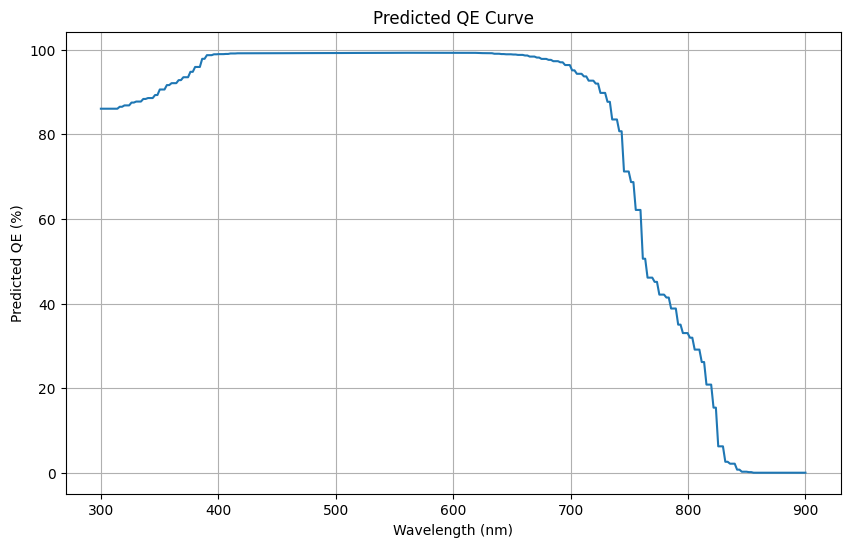

In [24]:
# =========================================================
# RUN FULL QE CURVE PREDICTION
# =========================================================

predict_qe_curve()

In [25]:
# =========================================================
# RESPONSIVITY DATA PREPROCESSING
# =========================================================

r_df = optimized_df[['lambda(nm).1', 'R[A/W]']].copy()

# Rename columns
r_df.rename(
    columns={
        'lambda(nm).1': 'Wavelength',
        'R[A/W]': 'Responsivity'
    },
    inplace=True
)

# Remove NaN values
r_df.dropna(inplace=True)

# Convert to numeric
r_df['Wavelength'] = pd.to_numeric(r_df['Wavelength'])
r_df['Responsivity'] = pd.to_numeric(r_df['Responsivity'])

# Reset index
r_df.reset_index(drop=True, inplace=True)

print("Responsivity Data Ready!")
print()

print("Shape:")
print(r_df.shape)

print()
print(r_df.head())

Responsivity Data Ready!

Shape:
(61, 2)

   Wavelength  Responsivity
0         300      0.204626
1         310      0.213896
2         320      0.223406
3         330      0.233200
4         340      0.243338


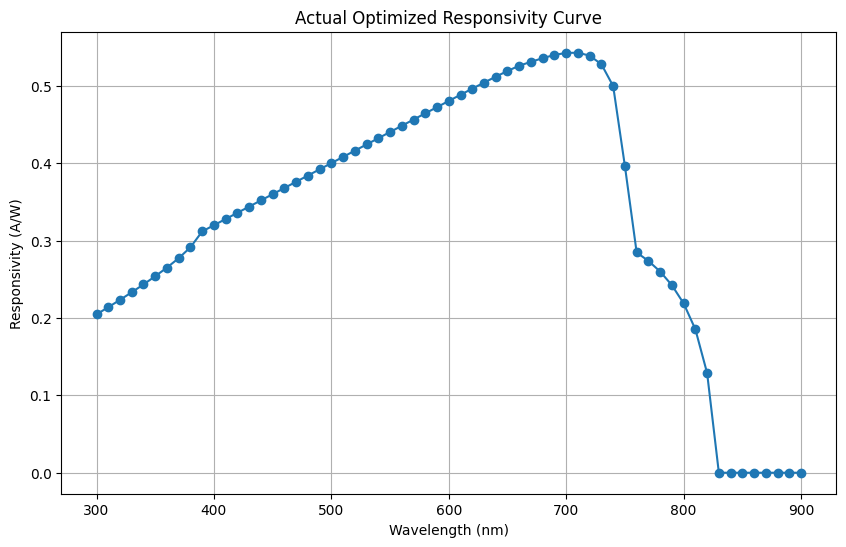

In [26]:
# =========================================================
# PLOT ACTUAL RESPONSIVITY CURVE
# =========================================================

plt.figure(figsize=(10,6))

plt.plot(
    r_df['Wavelength'],
    r_df['Responsivity'],
    marker='o'
)

plt.title("Actual Optimized Responsivity Curve")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Responsivity (A/W)")

plt.grid(True)

plt.show()

In [27]:
# =========================================================
# RESPONSIVITY MACHINE LEARNING MODEL
# =========================================================

# Features and target
X_r = r_df[['Wavelength']]
y_r = r_df['Responsivity']

# Train-test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_r,
    y_r,
    test_size=0.2,
    random_state=42
)

# Model
r_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train model
r_model.fit(X_train_r, y_train_r)

# Predictions
y_pred_r = r_model.predict(X_test_r)

print("Responsivity Model Trained Successfully!")

Responsivity Model Trained Successfully!


In [28]:
# =========================================================
# RESPONSIVITY MODEL VALIDATION
# =========================================================

# Performance Metrics
r2 = r2_score(y_test_r, y_pred_r)
mae = mean_absolute_error(y_test_r, y_pred_r)

print("RESPONSIVITY MODEL PERFORMANCE")
print("="*40)

print("R² Score:", r2)
print("MAE:", mae)



RESPONSIVITY MODEL PERFORMANCE
R² Score: 0.9767528722283556
MAE: 0.010964268306712693


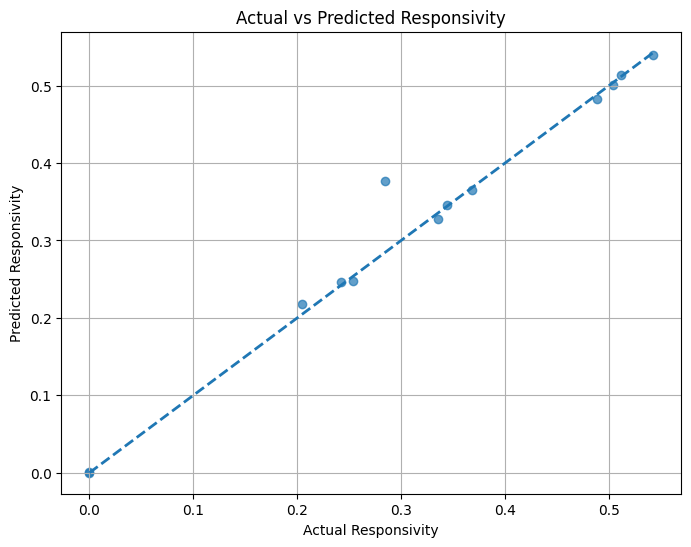

In [29]:
# =========================================================
# ACTUAL vs PREDICTED SCATTER PLOT
# =========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test_r,
    y_pred_r,
    alpha=0.7
)

# Ideal line
min_val = min(y_test_r.min(), y_pred_r.min())
max_val = max(y_test_r.max(), y_pred_r.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    '--',
    linewidth=2
)

plt.xlabel("Actual Responsivity")
plt.ylabel("Predicted Responsivity")

plt.title("Actual vs Predicted Responsivity")

plt.grid(True)

plt.show()

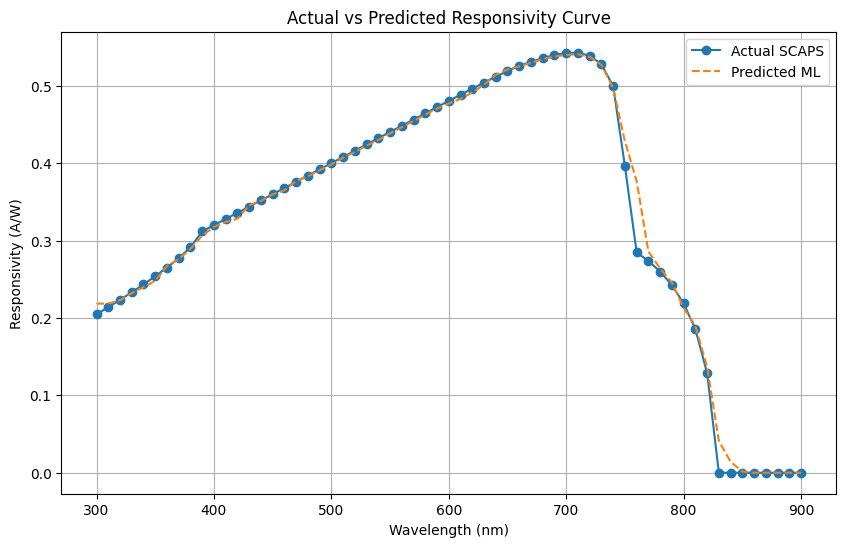

In [30]:
# =========================================================
# ACTUAL vs PREDICTED RESPONSIVITY CURVE
# =========================================================

# Predict full curve
full_pred_r = r_model.predict(X_r)

# Plot
plt.figure(figsize=(10,6))

# Actual curve
plt.plot(
    r_df['Wavelength'],
    r_df['Responsivity'],
    marker='o',
    label='Actual SCAPS'
)

# Predicted curve
plt.plot(
    r_df['Wavelength'],
    full_pred_r,
    '--',
    label='Predicted ML'
)

plt.title("Actual vs Predicted Responsivity Curve")

plt.xlabel("Wavelength (nm)")
plt.ylabel("Responsivity (A/W)")

plt.legend()
plt.grid(True)

plt.show()

In [31]:
# =========================================================
# RESPONSIVITY PREDICTION FUNCTION
# =========================================================

def predict_responsivity(wavelength):

    prediction = r_model.predict([[wavelength]])[0]

    print(f"Predicted Responsivity at {wavelength} nm : {prediction}")

    return prediction

In [32]:
# =========================================================
# USER INPUT PREDICTION
# =========================================================

wavelength = float(input("Enter Wavelength (nm): "))

predict_responsivity(wavelength)

Predicted Responsivity at 500.0 nm : 0.39838465804838713


c:\Users\yashv\anaconda3\envs\py312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


np.float64(0.39838465804838713)

In [33]:
# =========================================================
# FULL RESPONSIVITY CURVE PREDICTION
# =========================================================

def predict_responsivity_curve():

    wavelength_range = np.linspace(
        r_df['Wavelength'].min(),
        r_df['Wavelength'].max(),
        300
    )

    predicted_r = r_model.predict(
        wavelength_range.reshape(-1,1)
    )

    plt.figure(figsize=(10,6))

    plt.plot(
        wavelength_range,
        predicted_r
    )

    plt.title("Predicted Responsivity Curve")

    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Predicted Responsivity (A/W)")

    plt.grid(True)

    plt.show()

c:\Users\yashv\anaconda3\envs\py312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


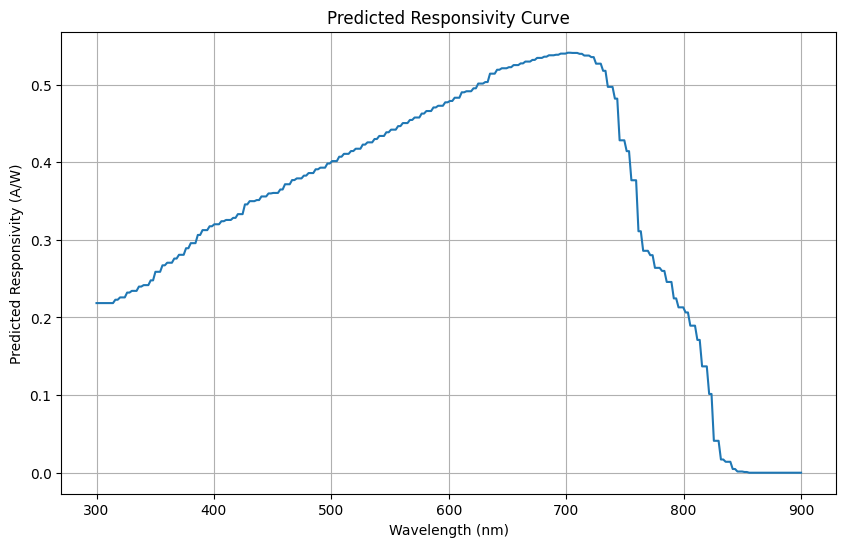

In [34]:
# =========================================================
# RUN FULL RESPONSIVITY CURVE PREDICTION
# =========================================================

predict_responsivity_curve()

In [35]:
# =========================================================
# DETECTIVITY DATA PREPROCESSING
# =========================================================

d_df = optimized_df[['V(V)', 'D*']].copy()

# Rename columns
d_df.rename(
    columns={
        'V(V)': 'Voltage',
        'D*': 'Detectivity'
    },
    inplace=True
)

# Remove NaN values
d_df.dropna(inplace=True)

# Convert to numeric
d_df['Voltage'] = pd.to_numeric(d_df['Voltage'])
d_df['Detectivity'] = pd.to_numeric(d_df['Detectivity'])

# Reset index
d_df.reset_index(drop=True, inplace=True)

print("Detectivity Data Ready!")
print()

print("Shape:")
print(d_df.shape)

print()
print(d_df.head())

Detectivity Data Ready!

Shape:
(35, 2)

   Voltage   Detectivity
0     1.20  5.065000e+15
1     1.15  5.294454e+15
2     1.10  5.529858e+15
3     1.05  5.772268e+15
4     1.00  6.023230e+15


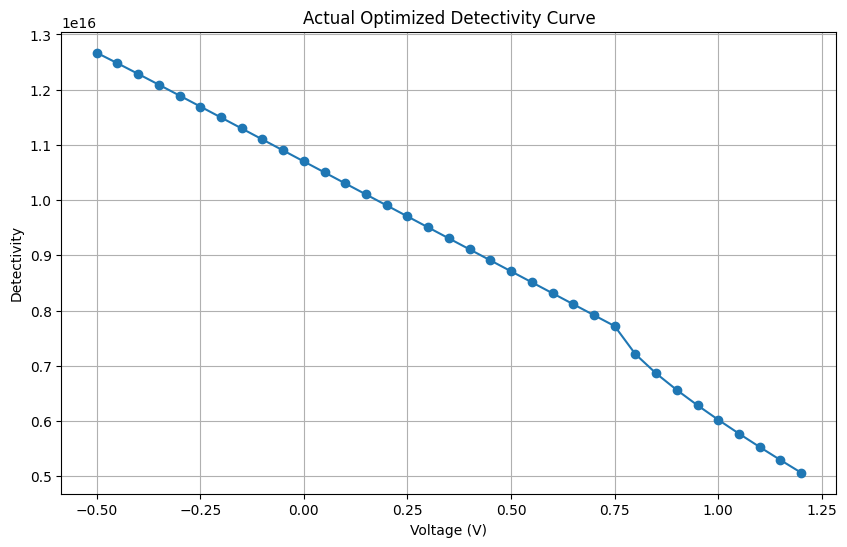

In [36]:
# =========================================================
# PLOT ACTUAL DETECTIVITY CURVE
# =========================================================

plt.figure(figsize=(10,6))

plt.plot(
    d_df['Voltage'],
    d_df['Detectivity'],
    marker='o'
)

plt.title("Actual Optimized Detectivity Curve")

plt.xlabel("Voltage (V)")
plt.ylabel("Detectivity")

plt.grid(True)

plt.show()

In [37]:
# =========================================================
# DETECTIVITY MACHINE LEARNING MODEL
# =========================================================

# Features and target
X_d = d_df[['Voltage']]
y_d = d_df['Detectivity']

# Train-test split
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_d,
    y_d,
    test_size=0.2,
    random_state=42
)

# Model
d_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train model
d_model.fit(X_train_d, y_train_d)

# Predictions
y_pred_d = d_model.predict(X_test_d)

print("Detectivity Model Trained Successfully!")

Detectivity Model Trained Successfully!


In [38]:
# =========================================================
# DETECTIVITY MODEL VALIDATION
# =========================================================

# Performance Metrics
r2 = r2_score(y_test_d, y_pred_d)
mae = mean_absolute_error(y_test_d, y_pred_d)

print("DETECTIVITY MODEL PERFORMANCE")
print("="*40)

print("R² Score:", r2)
print("MAE:", mae)

DETECTIVITY MODEL PERFORMANCE
R² Score: 0.9954374661027329
MAE: 66951671747388.71


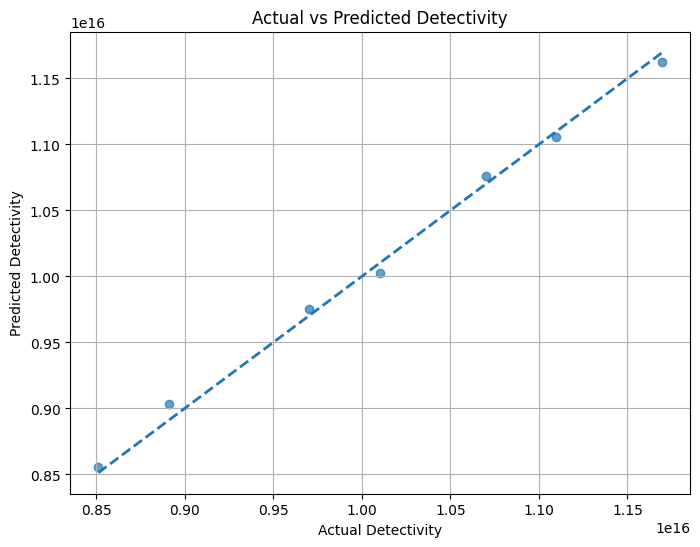

In [39]:
# =========================================================
# ACTUAL vs PREDICTED SCATTER PLOT
# =========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test_d,
    y_pred_d,
    alpha=0.7
)

# Ideal line
min_val = min(y_test_d.min(), y_pred_d.min())
max_val = max(y_test_d.max(), y_pred_d.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    '--',
    linewidth=2
)

plt.xlabel("Actual Detectivity")
plt.ylabel("Predicted Detectivity")

plt.title("Actual vs Predicted Detectivity")

plt.grid(True)

plt.show()

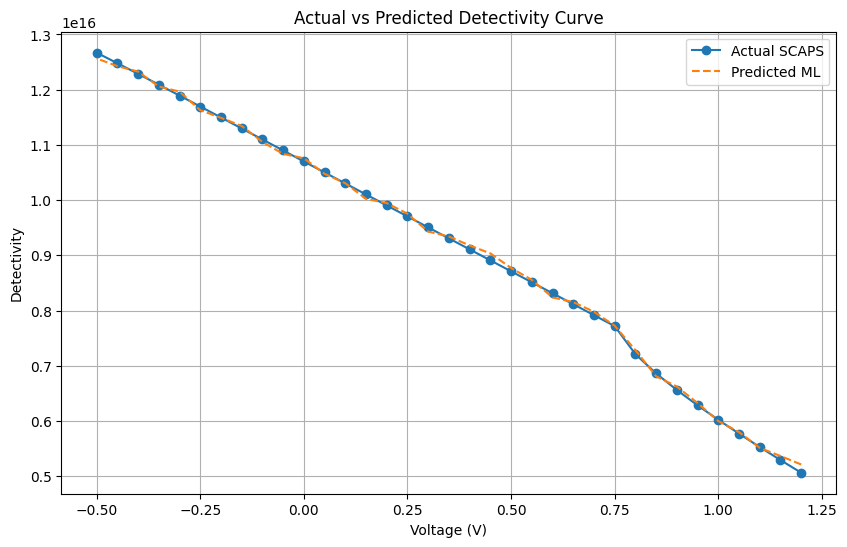

In [40]:
# =========================================================
# ACTUAL vs PREDICTED DETECTIVITY CURVE
# =========================================================

# Predict full curve
full_pred_d = d_model.predict(X_d)

# Plot
plt.figure(figsize=(10,6))

# Actual curve
plt.plot(
    d_df['Voltage'],
    d_df['Detectivity'],
    marker='o',
    label='Actual SCAPS'
)

# Predicted curve
plt.plot(
    d_df['Voltage'],
    full_pred_d,
    '--',
    label='Predicted ML'
)

plt.title("Actual vs Predicted Detectivity Curve")

plt.xlabel("Voltage (V)")
plt.ylabel("Detectivity")

plt.legend()
plt.grid(True)

plt.show()

In [41]:
# =========================================================
# DETECTIVITY PREDICTION FUNCTION
# =========================================================

def predict_detectivity(voltage):

    prediction = d_model.predict([[voltage]])[0]

    print(f"Predicted Detectivity at {voltage} V : {prediction}")

    return prediction

In [42]:
# =========================================================
# USER INPUT PREDICTION
# =========================================================

voltage = float(input("Enter Voltage (V): "))

predict_detectivity(voltage)

Predicted Detectivity at 5.0 V : 5214142283515640.0


c:\Users\yashv\anaconda3\envs\py312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


np.float64(5214142283515640.0)

In [43]:
# =========================================================
# FULL DETECTIVITY CURVE PREDICTION
# =========================================================

def predict_detectivity_curve():

    voltage_range = np.linspace(
        d_df['Voltage'].min(),
        d_df['Voltage'].max(),
        300
    )

    predicted_d = d_model.predict(
        voltage_range.reshape(-1,1)
    )

    plt.figure(figsize=(10,6))

    plt.plot(
        voltage_range,
        predicted_d
    )

    plt.title("Predicted Detectivity Curve")

    plt.xlabel("Voltage (V)")
    plt.ylabel("Predicted Detectivity")

    plt.grid(True)

    plt.show()

c:\Users\yashv\anaconda3\envs\py312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


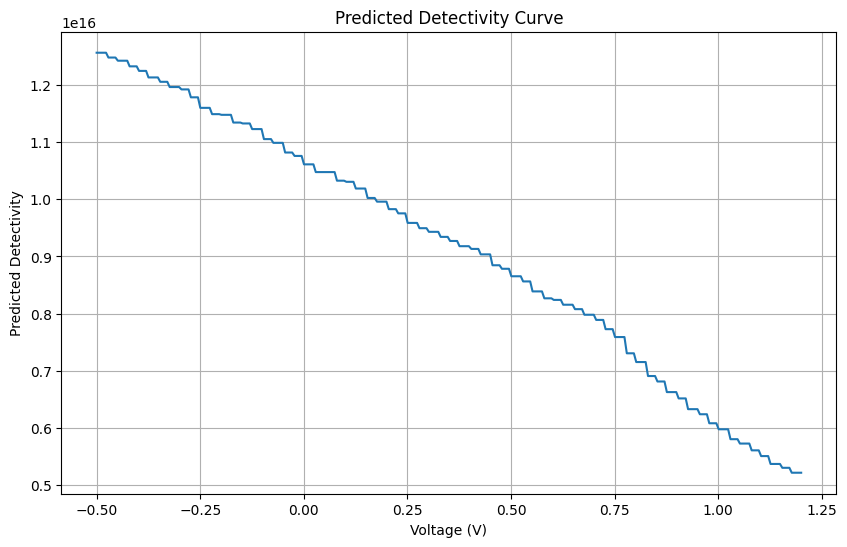

In [ ]:
# =========================================================
# RUN FULL DETECTIVITY CURVE PREDICTION
# =========================================================

predict_detectivity_curve()

In [47]:
# =========================================================
# MODEL PERFORMANCE SUMMARY
# =========================================================

print("="*60)
print("OPTIMIZED DEVICE ML MODEL SUMMARY")
print("="*60)

print()

print("J-V MODEL")
print("-"*30)
print("R² Score :", r2_score(y_test_jv, y_pred_jv))
print("MAE      :", mean_absolute_error(y_test_jv, y_pred_jv))

print()

print("QE MODEL")
print("-"*30)
print("R² Score :", r2_score(y_test_qe, y_pred_qe))
print("MAE      :", mean_absolute_error(y_test_qe, y_pred_qe))

print()

print("RESPONSIVITY MODEL")
print("-"*30)
print("R² Score :", r2_score(y_test_r, y_pred_r))
print("MAE      :", mean_absolute_error(y_test_r, y_pred_r))

print()

print("DETECTIVITY MODEL")
print("-"*30)
print("R² Score :", r2_score(y_test_d, y_pred_d))
print("MAE      :", mean_absolute_error(y_test_d, y_pred_d))

print()
print("="*60)

OPTIMIZED DEVICE ML MODEL SUMMARY

J-V MODEL
------------------------------
R² Score : 0.8559042726958324
MAE      : 0.0005043356249521125

QE MODEL
------------------------------
R² Score : 0.9858794642447958
MAE      : 1.4823678462651841

RESPONSIVITY MODEL
------------------------------
R² Score : 0.9767528722283556
MAE      : 0.010964268306712693

DETECTIVITY MODEL
------------------------------
R² Score : 0.9954374661027329
MAE      : 66951671747388.71



In [ ]:
# =========================================================
# FINAL PIPELINE STATUS
# =========================================================

print("""
============================================================
OPTIMIZED DEVICE PIPELINE COMPLETE
============================================================

Successfully Built:

1. J-V ML Pipeline
   • Actual Curve
   • ML Model
   • Actual vs Predicted
   • Point Prediction
   • Full Curve Prediction

2. QE ML Pipeline
   • Actual Curve
   • ML Model
   • Actual vs Predicted
   • Point Prediction
   • Full Curve Prediction

3. Responsivity ML Pipeline
   • Actual Curve
   • ML Model
   • Actual vs Predicted
   • Point Prediction
   • Full Curve Prediction

4. Detectivity ML Pipeline
   • Actual Curve
   • ML Model
   • Actual vs Predicted
   • Point Prediction
   • Full Curve Prediction

============================================================
FINAL SYSTEM CAPABILITIES
============================================================

• Visualization of optimized SCAPS curves
• ML-based curve learning
• Actual vs Predicted comparison
• Prediction for unseen values
• Full curve generation
• Device-performance analysis
• Validation framework

============================================================
RESEARCH SIGNIFICANCE
============================================================

This framework combines:
SCAPS Simulation + Optimization + Machine Learning

The system acts as:
• Predictive surrogate model
• Device characterization framework
• Optimized performance analysis system

============================================================
""")